In [1]:
import yfinance as yf
import pandas as pd

ticker = "AAPL"  # Apple — pick any you like later
data = yf.download(ticker, start="2020-01-01", end="2026-01-01")
data.head()

C:\Users\Simon Schmitz\AppData\Roaming\Python\Python313\site-packages\pandas\core\computation\expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2020-01-02,72.333862,72.394070,71.091169,71.344039,135480400
2020-01-03,71.630630,72.389250,71.406659,71.563198,146322800
2020-01-06,72.201408,72.239942,70.503546,70.754014,118387200
2020-01-07,71.861832,72.466315,71.642674,72.211033,108872000
2020-01-08,73.017830,73.318870,71.565614,71.565614,132079200


In [ ]:
print(len(data))
print(data.shape)
print(data.columns)
data.columns = data.columns.get_level_values(0)
print(data.columns)
print(data.columns)

1508
(1508, 5)
Index(['Close', 'High', 'Low', 'Open', 'Volume'], dtype='str', name='Price')
Index(['Close', 'High', 'Low', 'Open', 'Volume'], dtype='str', name='Price')
Index(['Close', 'High', 'Low', 'Open', 'Volume'], dtype='str', name='Price')


In [7]:
data.head()
data.tail()

Price,Close,High,Low,Open,Volume
Date,,,,,
2025-12-24,273.302216,274.919206,271.695216,271.834940,17910600
2025-12-26,272.893005,274.859353,272.353998,273.651606,21521800
2025-12-29,273.252350,273.851213,271.844961,272.184327,23715200
2025-12-30,272.573547,273.571693,271.775043,272.304059,22139600
2025-12-31,271.355835,273.172467,271.246054,272.553622,27293600


In [ ]:
data['Return'] = data['Close'].pct_change()#built in function for return
data.head()

Price,Close,High,Low,Open,Volume,Return
Date,,,,,,
2020-01-02,72.333862,72.394070,71.091169,71.344039,135480400,NaN
2020-01-03,71.630630,72.389250,71.406659,71.563198,146322800,-0.009722
2020-01-06,72.201408,72.239942,70.503546,70.754014,118387200,0.007968
2020-01-07,71.861832,72.466315,71.642674,72.211033,108872000,-0.004703
2020-01-08,73.017830,73.318870,71.565614,71.565614,132079200,0.016086


In [9]:
data = data.dropna()
print(len(data))

1507


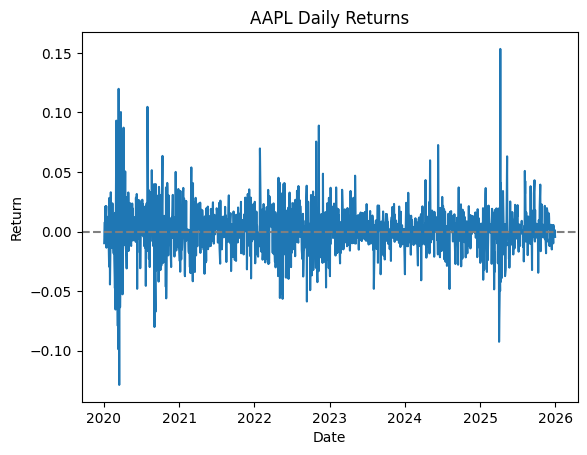

In [10]:
import matplotlib.pyplot as plt

plt.plot(data.index, data['Return'])
plt.axhline(0, color='gray', linestyle='--')
plt.title(f"{ticker} Daily Returns")
plt.xlabel("Date")
plt.ylabel("Return")
plt.show()

In [11]:
import sqlite3

conn = sqlite3.connect('volatility_project.db')
data.to_sql(f'{ticker}_prices', conn, if_exists='replace', index=True)

1507

In [12]:
query = f"SELECT * FROM {ticker}_prices ORDER BY Date DESC LIMIT 5"
result = pd.read_sql(query, conn)
print(result)

                  Date       Close        High         Low        Open  \
0  2025-12-31 00:00:00  271.355835  273.172467  271.246054  272.553622   
1  2025-12-30 00:00:00  272.573547  273.571693  271.775043  272.304059   
2  2025-12-29 00:00:00  273.252350  273.851213  271.844961  272.184327   
3  2025-12-26 00:00:00  272.893005  274.859353  272.353998  273.651606   
4  2025-12-24 00:00:00  273.302216  274.919206  271.695216  271.834940   

     Volume    Return  
0  27293600 -0.004467  
1  22139600 -0.002484  
2  23715200  0.001317  
3  21521800 -0.001497  
4  17910600  0.005324  


In [14]:
from statsmodels.tsa.stattools import adfuller
result_price = adfuller(data['Close'])#the standard stationarity test
print("ADF Statistic:", result_price[0])
print("p-value:", result_price[1])

ADF Statistic: -0.9333691975184811
p-value: 0.7767849759557246


In [15]:
result_return = adfuller(data['Return'])
print("ADF Statistic:", result_return[0])
print("p-value:", result_return[1])

ADF Statistic: -13.098684087980121
p-value: 1.7278952928522246e-24


In [18]:
data['RollingVol'] = data['Return'].rolling(window=20).std()#calculates the standard deviation of every 20 day window
data[['Return', 'RollingVol']]

Price,Return,RollingVol
Date,,
2020-01-03,-0.009722,NaN
2020-01-06,0.007968,NaN
2020-01-07,-0.004703,NaN
2020-01-08,0.016086,NaN
2020-01-09,0.021241,NaN
...,...,...
2025-12-24,0.005324,0.007907
2025-12-26,-0.001497,0.007884
2025-12-29,0.001317,0.007798


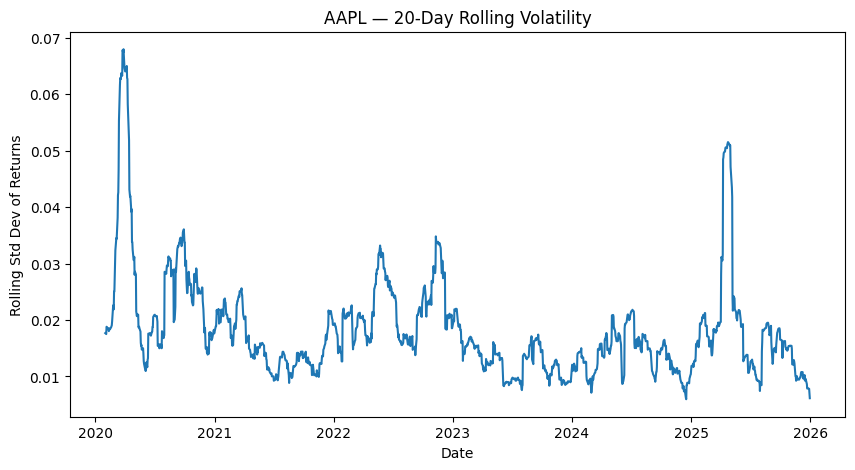

In [17]:
plt.figure(figsize=(10, 5))
plt.plot(data.index, data['RollingVol'])
plt.title(f"{ticker} — 20-Day Rolling Volatility")
plt.xlabel("Date")
plt.ylabel("Rolling Std Dev of Returns")
plt.show()